# PART B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS

In [1]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
print('NAME:  AKHIL C\nROLL NO:  24BAD007')

NAME:  AKHIL C
ROLL NO:  24BAD007


In [2]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Display the shape of the dataset
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


# PREPROCESSING THE DATASET

In [4]:
# Normalize the pixel values (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten 28x28 images into 784 features
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# One-Hot Encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Display the new shapes
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 784)
Testing Images: (10000, 784)
Training Labels: (60000, 10)
Testing Labels: (10000, 10)


# BUILD AND COMPILE THE ANN

In [ ]:
# Function to build and compile the ANN model
def build_model(activation):

    model = Sequential([
        Dense(128, activation=activation, input_shape=(784,)),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
activation_functions = ["relu","sigmoid", "tanh"]
history_dict = {}
evaluation_dict = {}

# TRAIN THE ANN

In [ ]:
for activation in activation_functions:
    print("-" * 50)
    print(f"Training Model with {activation.upper()} Activation")
    print("-" * 50)

    # Build model
    model = build_model(activation)

    # Train model
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    # Evaluate model
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Store results
    history_dict[activation] = history
    evaluation_dict[activation] = {
        "loss": loss,
        "accuracy": accuracy
    }
    print(f"\nFinal Test Loss     : {loss:.4f}")
    print(f"Final Test Accuracy : {accuracy:.4f}\n")

--------------------------------------------------
Training Model with RELU Activation
--------------------------------------------------
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9304 - loss: 0.2356 - val_accuracy: 0.9649 - val_loss: 0.1156
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9691 - loss: 0.1020 - val_accuracy: 0.9702 - val_loss: 0.0976
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9778 - loss: 0.0715 - val_accuracy: 0.9768 - val_loss: 0.0740
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9831 - loss: 0.0529 - val_accuracy: 0.9757 - val_loss: 0.0823
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9858 - loss: 0.0426 - val_accuracy: 0.9751 - val_loss: 0.0853
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9876 - loss: 0.0366 - val_accuracy: 0.9766 - val_loss: 0.0818
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9901 - loss: 

# COMPARISON TABLE

In [ ]:
print("\nActivation Function Comparison")
print("-" * 50)

for activation in activation_functions:
    print(
        f"{activation.upper():10} "
        f"Accuracy: {evaluation_dict[activation]['accuracy']:.4f} | "
        f"Loss: {evaluation_dict[activation]['loss']:.4f}"
    )


Activation Function Comparison
--------------------------------------------------
RELU       Accuracy: 0.9804 | Loss: 0.0763
SIGMOID    Accuracy: 0.9799 | Loss: 0.0701
TANH       Accuracy: 0.9763 | Loss: 0.0851


# VISUALIZATIONS

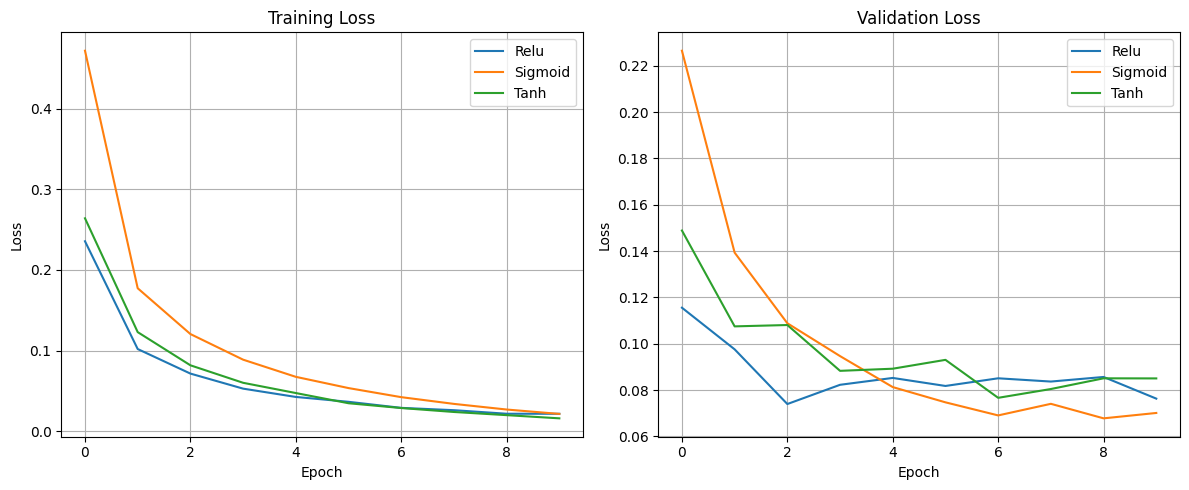

In [ ]:
plt.figure(figsize=(12, 5))

# Training Loss
plt.subplot(1, 2, 1)
for activation in activation_functions:
    plt.plot(
        history_dict[activation].history['loss'],
        label=f'{activation.capitalize()}'
    )
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Validation Loss
plt.subplot(1, 2, 2)

for activation in activation_functions:
    plt.plot(
        history_dict[activation].history['val_loss'],
        label=f'{activation.capitalize()}'
    )
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

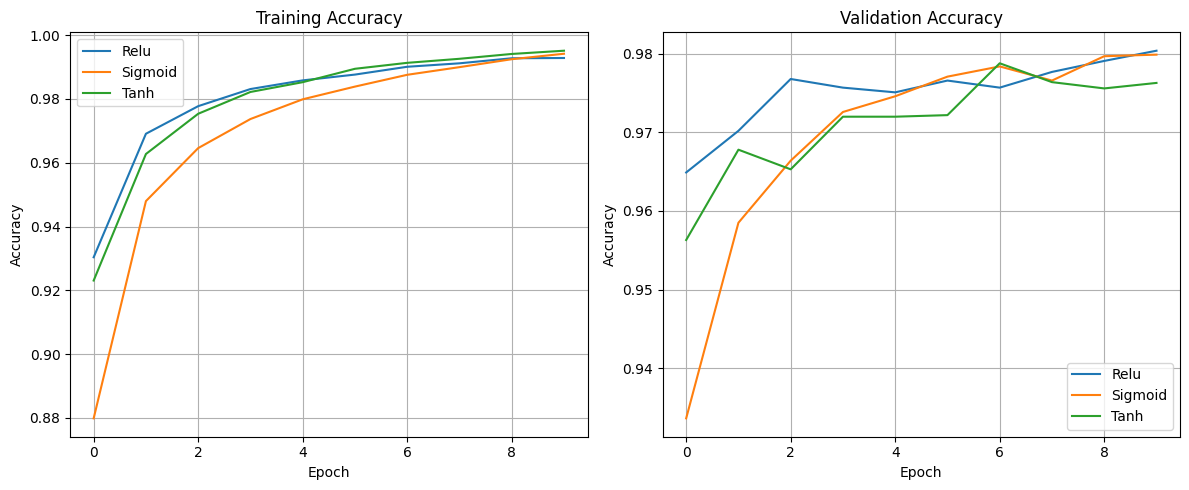

In [ ]:
plt.figure(figsize=(12, 5))

# Training Accuracy
plt.subplot(1, 2, 1)

for activation in activation_functions:
    plt.plot(
        history_dict[activation].history['accuracy'],
        label=f'{activation.capitalize()}'
    )

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


# Validation Accuracy
plt.subplot(1, 2, 2)

for activation in activation_functions:
    plt.plot(
        history_dict[activation].history['val_accuracy'],
        label=f'{activation.capitalize()}'
    )
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **PART C: COMPARISON OF OPTIMIZATION ALGORITHMS**

In [3]:
# Import optimizers

from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# BUILD AND COMPILE THE ANN

In [5]:
def build_model(optimizer):

    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
optimizers = {
    "SGD": SGD(),
    "Momentum": SGD(momentum=0.9),
    "RMSprop": RMSprop(),
    "Adam": Adam()
}
history_dict_C = {}
evaluation_dict_C = {}

# TRAIN THE ANN

In [8]:
for name, optimizer in optimizers.items():

    print("-" * 50)
    print(f"Training with {name}")
    print("-" * 50)

    model = build_model(optimizer)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=32,
        verbose=1
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    history_dict_C[name] = history

    evaluation_dict_C[name] = {
        "loss": loss,
        "accuracy": accuracy
    }

    print(f"\n{name} Results")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy:.4f}\n")

--------------------------------------------------
Training with SGD
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8393 - loss: 0.6007 - val_accuracy: 0.9114 - val_loss: 0.3103
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9179 - loss: 0.2887 - val_accuracy: 0.9279 - val_loss: 0.2465
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9330 - loss: 0.2369 - val_accuracy: 0.9392 - val_loss: 0.2054
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9422 - loss: 0.2030 - val_accuracy: 0.9438 - val_loss: 0.1852
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9492 - loss: 0.1781 - val_accuracy: 0.9503 - val_loss: 0.1651
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9546 - loss: 0.1588 - val_accuracy: 0.9550 - val_loss: 0.1517
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9590 - loss: 0.1427 - val_accuracy: 0.9581 - val_loss: 0.1374
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9627 - loss: 0.1298 - 

# COMPARISON TABLE

In [10]:
print("\nOptimizer Comparison")
print("-" * 50)

for name in optimizers.keys():

    print(
        f"{name:10} "
        f"Accuracy : {evaluation_dict_C[name]['accuracy']:.4f} | "
        f"Loss : {evaluation_dict_C[name]['loss']:.4f}"
    )


Optimizer Comparison
--------------------------------------------------
SGD        Accuracy : 0.9654 | Loss : 0.1118
Momentum   Accuracy : 0.9757 | Loss : 0.0870
RMSprop    Accuracy : 0.9777 | Loss : 0.1141
Adam       Accuracy : 0.9748 | Loss : 0.1042


# VISUALIZATIONS

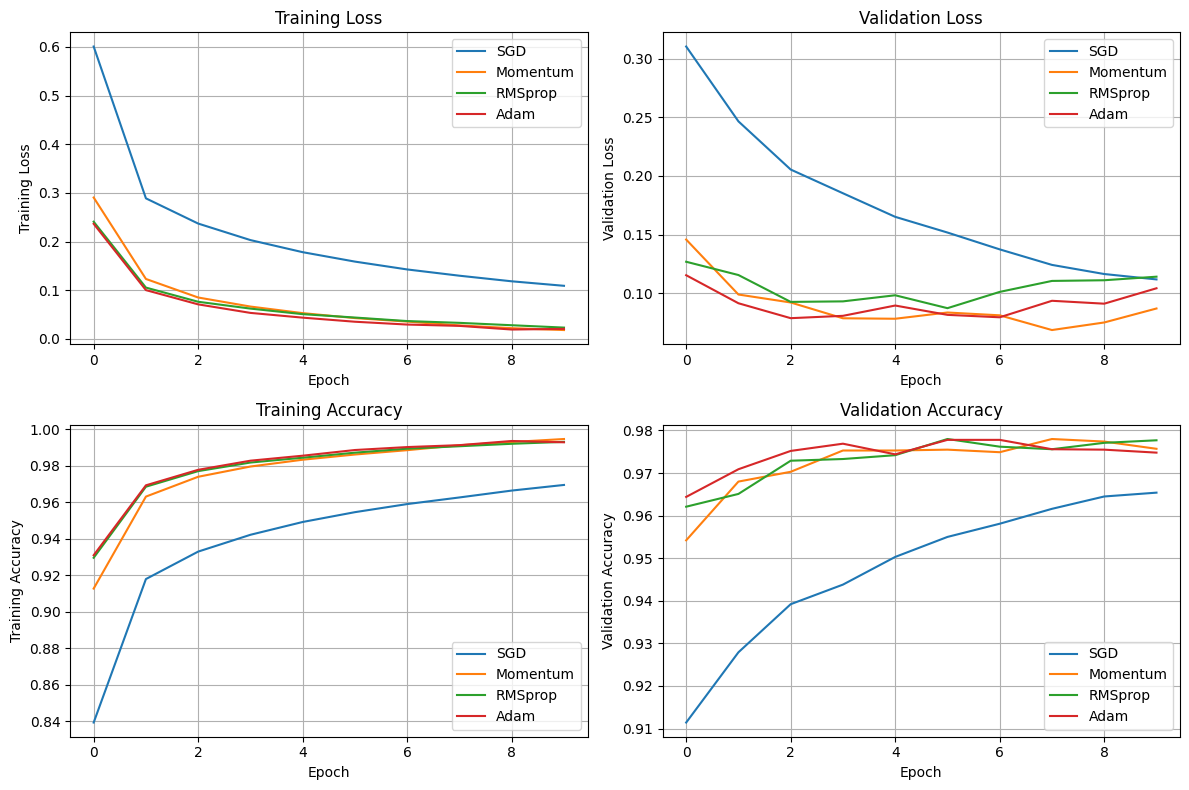

In [18]:
metrics = [('loss','Training Loss'),
           ('val_loss','Validation Loss'),
           ('accuracy','Training Accuracy'),
           ('val_accuracy','Validation Accuracy')]

plt.figure(figsize=(12,8))

for i, (metric, title) in enumerate(metrics, 1):
    plt.subplot(2,2,i)
    for name, h in history_dict_C.items():
        plt.plot(h.history[metric], label=name)
    plt.title(title)
    plt.ylabel(metrics[i-1][1])
    plt.xlabel("Epoch")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()